In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.pipeline import Pipeline
import time
import random

random.seed(100)


In [3]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [5]:
df.shape

(1338, 7)

In [6]:
df.info(verbose=True)
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df["sex"].value_counts().unique

<bound method Series.unique of sex
male      676
female    662
Name: count, dtype: int64>

In [8]:
df["sex"]=df["sex"].map({"male":0,"female":1})

In [9]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,0,30.97,3,no,northwest,10600.5483
1334,18,1,31.92,0,no,northeast,2205.9808
1335,18,1,36.85,0,no,southeast,1629.8335
1336,21,1,25.80,0,no,southwest,2007.9450
1337,61,1,29.07,0,yes,northwest,29141.3603


In [10]:
df["smoker"]=df["smoker"].map({"no":0,"yes":1})

In [11]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,0,30.97,3,0,northwest,10600.5483
1334,18,1,31.92,0,0,northeast,2205.9808
1335,18,1,36.85,0,0,southeast,1629.8335
1336,21,1,25.80,0,0,southwest,2007.9450
1337,61,1,29.07,0,1,northwest,29141.3603


In [12]:
df["region"].unique()

<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

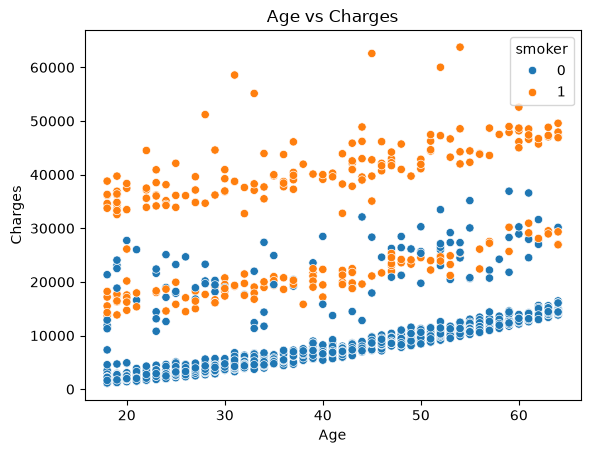

In [13]:
sns.scatterplot(x="age",y="charges",hue="smoker",data=df)
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.show()

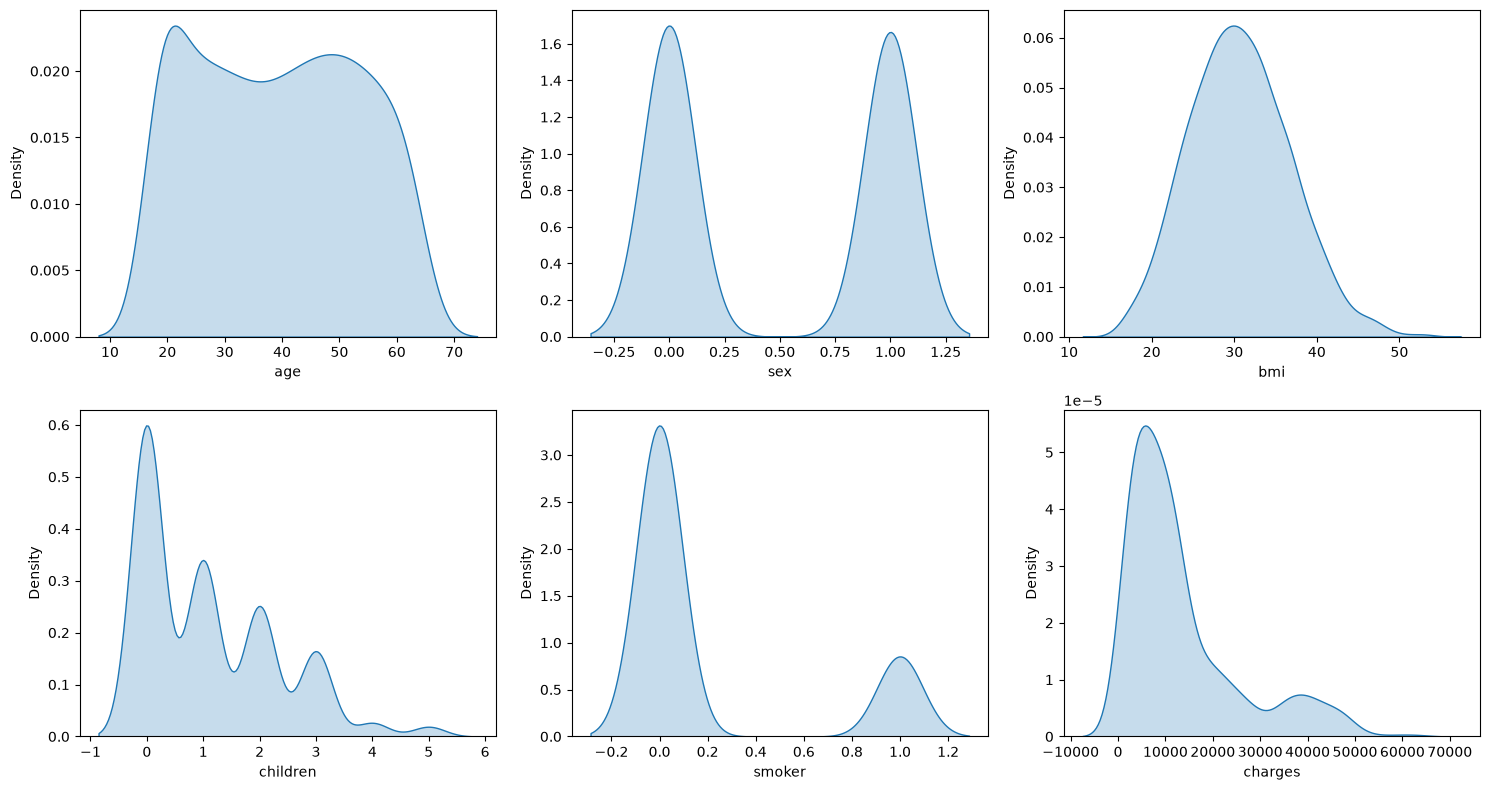

In [14]:
# Select numeric and categorical columns reliably
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(numerical_features) / n_cols))
plt.figure(figsize=(15, 4 * n_rows))

for i, feature in enumerate(numerical_features, start=1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(data=df, x=feature, fill=True)
    plt.xlabel(feature)
    plt.tight_layout()

plt.show()


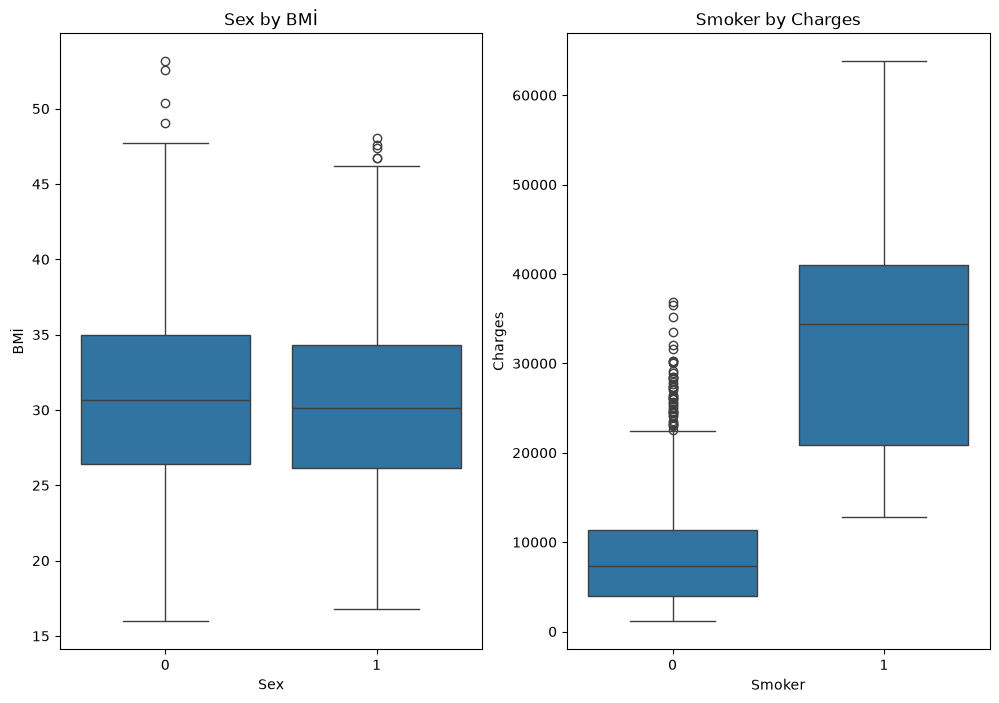

In [15]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.boxplot(x="sex",y="bmi",data=df)
plt.title("Sex by BMİ")
plt.xlabel("Sex")
plt.ylabel("BMİ")
plt.subplot(1,2,2)
sns.boxplot(x="smoker",y="charges",data=df)
plt.title("Smoker by Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

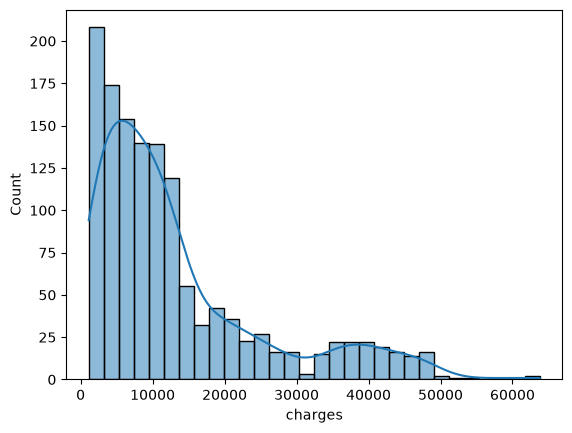

In [16]:
sns.histplot(data=df["charges"],kde=True)
plt.show()

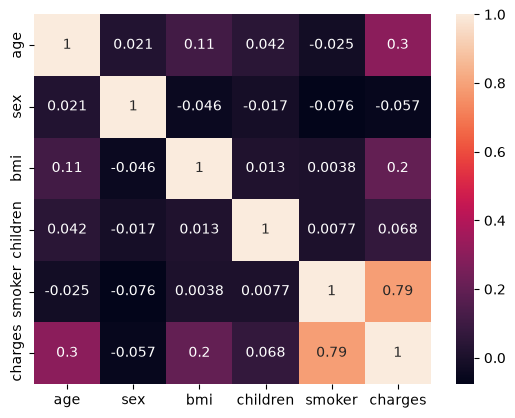

In [17]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

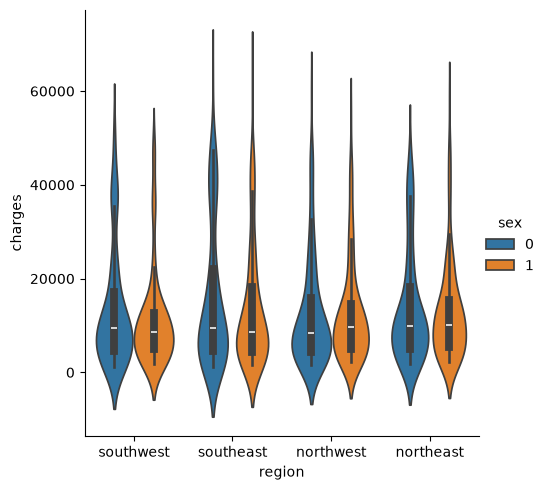

In [18]:
sns.catplot(x="region",y="charges",hue="sex",kind="violin",data=df)
plt.show()

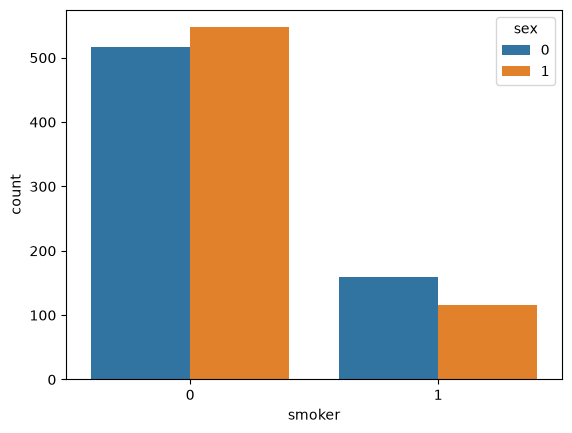

In [19]:
sns.countplot(x="smoker",hue="sex",data=df)
plt.show()

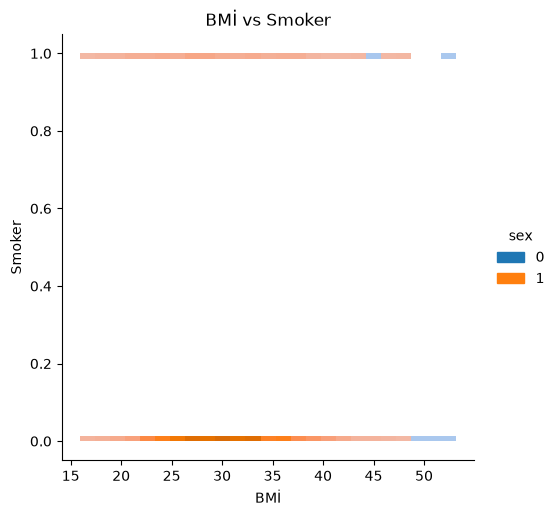

In [20]:
sns.displot(x="bmi",y="smoker",hue="sex",data=df)
plt.title("BMİ vs Smoker")
plt.xlabel("BMİ")
plt.ylabel("Smoker")
plt.show()

In [21]:
print(df["region"].value_counts())
df=pd.get_dummies(df,columns=["region"],drop_first=True)
print(df.columns)

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 66.8 KB


In [23]:
y = df["charges"] 
X = df.drop("charges", axis=1)

In [24]:
from  sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
X_train.shape

(1070, 8)

In [26]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 256.98, 18.59, 337.09,...,-370.68,-657.86,-809.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.195e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [27]:
model.coef_

array([ 2.56975706e+02,  1.85916916e+01,  3.37092552e+02,  4.25278784e+02,
        2.36511289e+04, -3.70677326e+02, -6.57864297e+02, -8.09799354e+02])

In [28]:
model.intercept_

np.float64(-11949.810741967709)

In [29]:
y_pred=model.predict(X_test)

In [30]:
y_pred[:5]

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656])

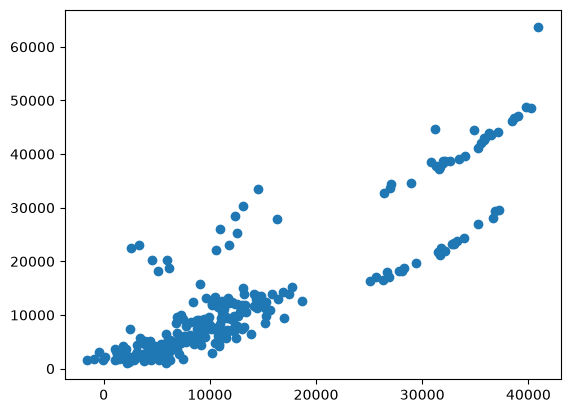

In [31]:
plt.scatter(y_pred,y_test)
plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse: ",mse)
print("mae: ",mae)
print("rmse: ",rmse)
print("r2: ",r2)

mse:  33596915.851361446
mae:  4181.194473753647
rmse:  5796.284659276272
r2:  0.7835929767120724


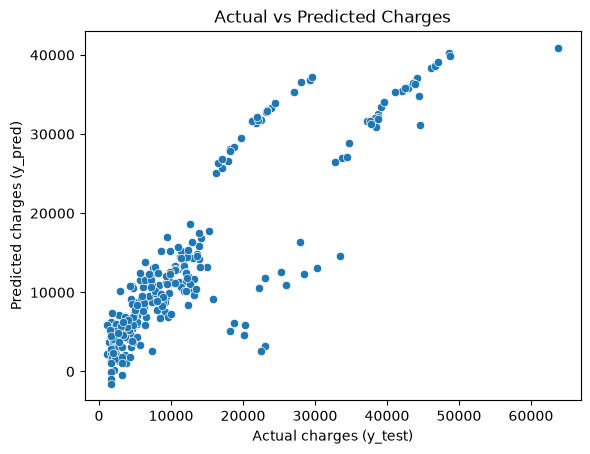

In [33]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual charges (y_test)")
plt.ylabel("Predicted charges (y_pred)")
plt.title("Actual vs Predicted Charges")
plt.show()
